In [10]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import GridSearchCV, GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, r2_score
import seaborn as sns


In [2]:
def analyze_svr_tuned(data, layer, plot_tuning=True):
    import pandas as pd
    import matplotlib.pyplot as plt

    feature_cols = [
        'mu', 'sigma',
        'feat_0','feat_1','feat_2','feat_3','feat_4','feat_5',
        'feat_6','feat_7','feat_8','feat_9','feat_10','feat_11',
        'feat_12','feat_13','feat_14','feat_15',
        'Bandstop Frequency', 'Bandstop Magnitude', 'BW',
        'Phase_1GHz_deg', 'Phase_2GHz_deg', 'Slope',
        'Age','Gender','Height[m]','Weight[kg]','BMI',
        'device'
    ]

    X = data[feature_cols].copy()
    X['Gender'] = X['Gender'].map({'M': 1, 'F': 0})
    X['device'] = X['device'].map({
        'CopperMountain': 0,
        'nanoVNA': 1,
        'NEW protocol': 1
    })

    if layer == 'muscle':
        y = data['Rfcsa[cm2]']
    elif layer == 'skin':
        y = data['Skin[mm]']
    elif layer == 'fat':
        y = data['Fat[mm]']
    else:
        raise ValueError("layer must be muscle, skin, or fat")

    df = X.copy()
    df['target'] = y
    df['group'] = data['volunteer']
    df = df.dropna()

    X = df[feature_cols]
    y = df['target']
    groups = df['group']

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]
    groups_train = groups.iloc[train_idx]

    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ])

    param_grid = {
        'svr__kernel': ['rbf'],
        'svr__C': [0.1, 1, 10, 50, 100],
        'svr__epsilon': [0.001, 0.01, 0.05, 0.1, 0.2],
        'svr__gamma': ['scale', 'auto', 0.001, 0.01, 0.1, 1]
    }

    cv = GroupKFold(n_splits=5)

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        scoring='neg_mean_absolute_error',
        cv=cv,
        n_jobs=-1,
        verbose=2,
        return_train_score=True
    )

    grid.fit(X_train, y_train, groups=groups_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results = pd.DataFrame(grid.cv_results_)
    results['mean_val_mae'] = -results['mean_test_score']
    results['std_val_mae'] = results['std_test_score']
    results['mean_train_mae'] = -results['mean_train_score']
    results = results.sort_values('mean_val_mae').reset_index(drop=True)

    if plot_tuning:
        plt.figure(figsize=(12, 5))
        plt.plot(
            results.index,
            results['mean_val_mae'],
            marker='o',
            label='Validation MAE'
        )
        plt.plot(
            results.index,
            results['mean_train_mae'],
            marker='o',
            label='Training MAE'
        )
        plt.fill_between(
            results.index,
            results['mean_val_mae'] - results['std_val_mae'],
            results['mean_val_mae'] + results['std_val_mae'],
            alpha=0.2
        )

        plt.xlabel("Hyperparameter Combination Rank")
        plt.ylabel("MAE")
        plt.title(f"SVR Hyperparameter Tuning Curve - {layer}")
        plt.legend()
        plt.grid(True)
        plt.show()

    print("Best parameters:", grid.best_params_)
    print("Best CV MAE:", -grid.best_score_)
    print("Test MAE:", mae)
    print("Test R2:", r2)

    return best_model, grid.best_params_, results, X_test, y_test, y_pred, mae, r2

In [3]:
def analyze(data, layer, mode,params=None):

    resonance_cols = ['Bandstop Frequency',
        'Bandstop Magnitude',
        'BW',
        'Phase_1GHz_deg',
        'Phase_2GHz_deg',
        'Slope']

    autoencoder_cols = ['mu', 'sigma',

        'feat_0','feat_1','feat_2','feat_3','feat_4','feat_5',
        'feat_6','feat_7','feat_8','feat_9','feat_10','feat_11',
        'feat_12','feat_13','feat_14','feat_15']

    demographics_cols = ['Age','Gender','Height[m]','Weight[kg]','BMI']

    microwave_cols = ['mu', 'sigma',

        'feat_0','feat_1','feat_2','feat_3','feat_4','feat_5',
        'feat_6','feat_7','feat_8','feat_9','feat_10','feat_11',
        'feat_12','feat_13','feat_14','feat_15',

        'Bandstop Frequency',
        'Bandstop Magnitude',
        'BW',
        'Phase_1GHz_deg',
        'Phase_2GHz_deg',
        'Slope']

    full = [
        'mu', 'sigma',

        'feat_0','feat_1','feat_2','feat_3','feat_4','feat_5',
        'feat_6','feat_7','feat_8','feat_9','feat_10','feat_11',
        'feat_12','feat_13','feat_14','feat_15',

        'Bandstop Frequency',
        'Bandstop Magnitude',
        'BW',
        'Phase_1GHz_deg',
        'Phase_2GHz_deg',
        'Slope',

        'Age','Gender','Height[m]','Weight[kg]','BMI',

        'device'
    ]

    if mode == 'resonance_only':
        feature_cols = resonance_cols
    elif mode == 'autoencoder_only':
        feature_cols = autoencoder_cols
    elif mode == 'demographics_only':
        feature_cols = demographics_cols
    else:
        feature_cols = full

    X = data[feature_cols].copy()

    if 'Gender' in X.columns:
        X['Gender'] = X['Gender'].map({'M': 1, 'F': 0})
    if 'device' in X.columns:
      X['device'] = X['device'].map({
        'CopperMountain': 0,
        'nanoVNA': 1,
        'NEW protocol': 1})

    if layer == 'muscle':
        y = data['Rfcsa[cm2]']
    elif layer == 'skin':
        y = data['Skin[mm]']
    elif layer == 'fat':
        y = data['Fat[mm]']
    else:
        raise ValueError("layer must be one of: muscle, skin, fat")

    # keep groups aligned before dropping rows
    groups = data['volunteer']

    df = X.copy()
    df['target'] = y
    df['group'] = groups

    df = df.dropna()

    X = df[feature_cols]
    y = df['target']
    groups = df['group']

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    #Best parameters:
    if params is None:
      c, epsilon, gamma, kernel = 10, 0.01, 'scale', 'rbf'
    else:
      c, epsilon, gamma, kernel = params['svr__C'], params['svr__epsilon'], params['svr__gamma'], params['svr__kernel']

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel=kernel, C=c, epsilon=epsilon))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return model, X_test, y_test, y_pred, mae, r2

In [8]:
def plot_target_correlation(data, target):
    feature_cols = [
        'mu', 'sigma',
        'feat_0','feat_1','feat_2','feat_3','feat_4','feat_5',
        'feat_6','feat_7','feat_8','feat_9','feat_10','feat_11',
        'feat_12','feat_13','feat_14','feat_15',
        'Bandstop Frequency',
        'Bandstop Magnitude',
        'BW',
        'Phase_1GHz_deg',
        'Phase_2GHz_deg',
        'Slope',
        'Age','Gender','Height[m]','Weight[kg]','BMI','device'
    ]

    df = data[feature_cols].copy()

    df['Gender'] = df['Gender'].map({'M':1,'F':0})
    df['device'] = df['device'].map({
        'CopperMountain':0,
        'nanoVNA':1,
        'NEW protocol':1
    })

    df['target'] = data[target]
    df = df.dropna()

    corr = df.corr()['target'].sort_values(ascending=False)

    plt.figure(figsize=(8, 10))

    sns.heatmap(
        corr.to_frame(),
        annot=True,
        cmap='coolwarm',
        center=0
    )

    plt.title(f'Feature Correlation with {target}')
    plt.tight_layout()
    plt.show()

    return corr

In [15]:
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
import pandas as pd

def plot_feature_importance(model, X_test, y_test, title="Feature Importance"):
    result = permutation_importance(
        model,
        X_test,
        y_test,
        scoring='neg_mean_absolute_error',
        n_repeats=20,
        random_state=42,
        n_jobs=-1
    )

    importance_df = pd.DataFrame({
        'feature': X_test.columns,
        'importance': result.importances_mean
    }).sort_values('importance', ascending=False)

    plt.figure(figsize=(10, 8))

    plt.barh(
        importance_df['feature'],
        importance_df['importance']
    )

    plt.xlabel("Permutation Importance")
    plt.ylabel("Features")
    plt.title(title)
    plt.gca().invert_yaxis()
    plt.grid(axis='x')
    plt.tight_layout()
    plt.show()

    return importance_df

In [13]:
def grouped_importance(importance_df):
    groups = {
        'Autoencoder': [
            'mu','sigma',
            'feat_0','feat_1','feat_2','feat_3','feat_4','feat_5',
            'feat_6','feat_7','feat_8','feat_9','feat_10','feat_11',
            'feat_12','feat_13','feat_14','feat_15'
        ],
        'Resonance': [
            'Bandstop Frequency',
            'Bandstop Magnitude',
            'BW',
            'Phase_1GHz_deg',
            'Phase_2GHz_deg',
            'Slope'
        ],
        'Demographics': [
            'Age','Gender','Height[m]','Weight[kg]','BMI'
        ],
        'Device': ['device']
    }

    group_scores = {}

    for group_name, feats in groups.items():
        score = importance_df[
            importance_df['feature'].isin(feats)
        ]['importance'].sum()

        group_scores[group_name] = score

    group_df = pd.DataFrame(
        list(group_scores.items()),
        columns=['group', 'importance']
    )

    plt.figure(figsize=(8,5))

    plt.bar(
        group_df['group'],
        group_df['importance']
    )

    plt.ylabel("Total Importance")
    plt.title("Grouped Feature Importance")
    plt.grid(axis='y')
    plt.show()

    return group_df

In [4]:
data_path = ['/content/drive/MyDrive/Data/prepared data/autoencoder_dataset.csv','/content/drive/MyDrive/Data/prepared data/de_autoencoder_comb_dataset.csv',
             '/content/drive/MyDrive/Data/prepared data/de_autoencoder_mask_dataset.csv','/content/drive/MyDrive/Data/prepared data/de_autoencoder_gauss_dataset.csv']
result = [['dataset','layer','mode','mae','r_square']]
for i in data_path:
  data = pd.read_csv(i)
  dataset = i.split('/')[-1].split('.')[0]

  for layer in ['muscle','skin','fat']:

    for mode in ['resonance_only','autoencoder_only','demographics_only','microwave_only','full']:

      # best_model, best_tuned_params, results, X_test, y_test, y_pred, mae, r2 = analyze_svr_tuned(data,layer)
      model, X_test, y_test, y_pred, mae, r2 = analyze(data,layer,mode)

    # y_pred = model.predict(X_test)
    # mae = mean_absolute_error(y_test, y_pred)
    # r2    = r2_score(y_test, y_pred)
      res = pd.concat([X_test, y_test.rename('y_test'), pd.Series(y_pred, index=X_test.index).rename('y_predicted')], axis=1)

      res.to_csv(f'/content/drive/MyDrive/Data/Result/result_{dataset}_{layer}_{mode}.csv')
      result.append([dataset,layer,mode,mae,r2])

In [5]:
df_result = pd.DataFrame(result[1:], columns=result[0])
df_result.to_csv('/content/drive/MyDrive/Data/Result/result_model_comparisons.csv')
df_result

,dataset,layer,mode,mae,r_square
0,autoencoder_dataset,muscle,resonance_only,1.801958,-0.023727
1,autoencoder_dataset,muscle,autoencoder_only,1.934774,-0.243135
2,autoencoder_dataset,muscle,demographics_only,4.558611,-129.650525
3,autoencoder_dataset,muscle,microwave_only,1.840103,-19.431992
4,autoencoder_dataset,muscle,full,1.840103,-19.431992
5,autoencoder_dataset,skin,resonance_only,0.251085,-0.353488
6,autoencoder_dataset,skin,autoencoder_only,0.285246,-0.835552
7,autoencoder_dataset,skin,demographics_only,0.320706,-2.894859
8,autoencoder_dataset,skin,microwave_only,0.258110,-0.194159
9,autoencoder_dataset,skin,full,0.258110,-0.194159


Index(['Unnamed: 0', 'dataset', 'layer', 'mode', 'mae', 'r_square'], dtype='object')


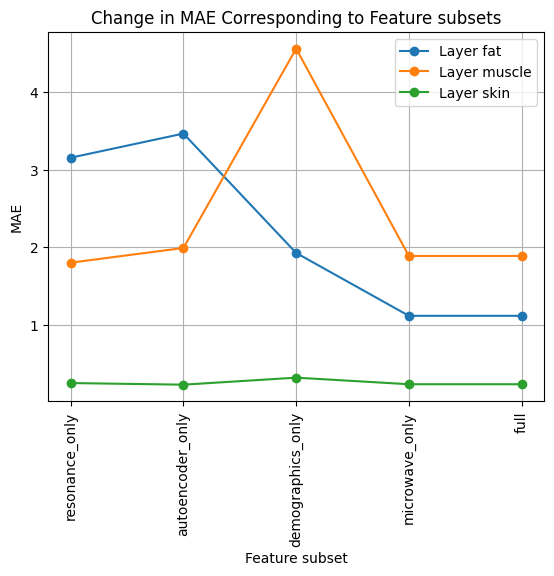

In [6]:
import matplotlib.pyplot as plt
data = pd.read_csv('/content/drive/MyDrive/Data/Result/result_model_comparisons.csv')
print(data.columns)
data = data[data['dataset'] == 'de_autoencoder_gauss_dataset']

for layer_name, group in data.groupby('layer'):
    plt.plot(group['mode'], group['mae'], marker='o', label=f'Layer {layer_name}')

y_min = data['mae'].min()
y_max = data['mae'].max()
# plt.yticks(np.arange(np.floor(y_min), np.ceil(y_max) + 0.25, 0.25))

plt.xlabel('Feature subset')
plt.ylabel('MAE')
plt.title('Change in MAE Corresponding to Feature subsets')
plt.xticks(rotation=90)
plt.legend()
plt.grid(True)
plt.show()

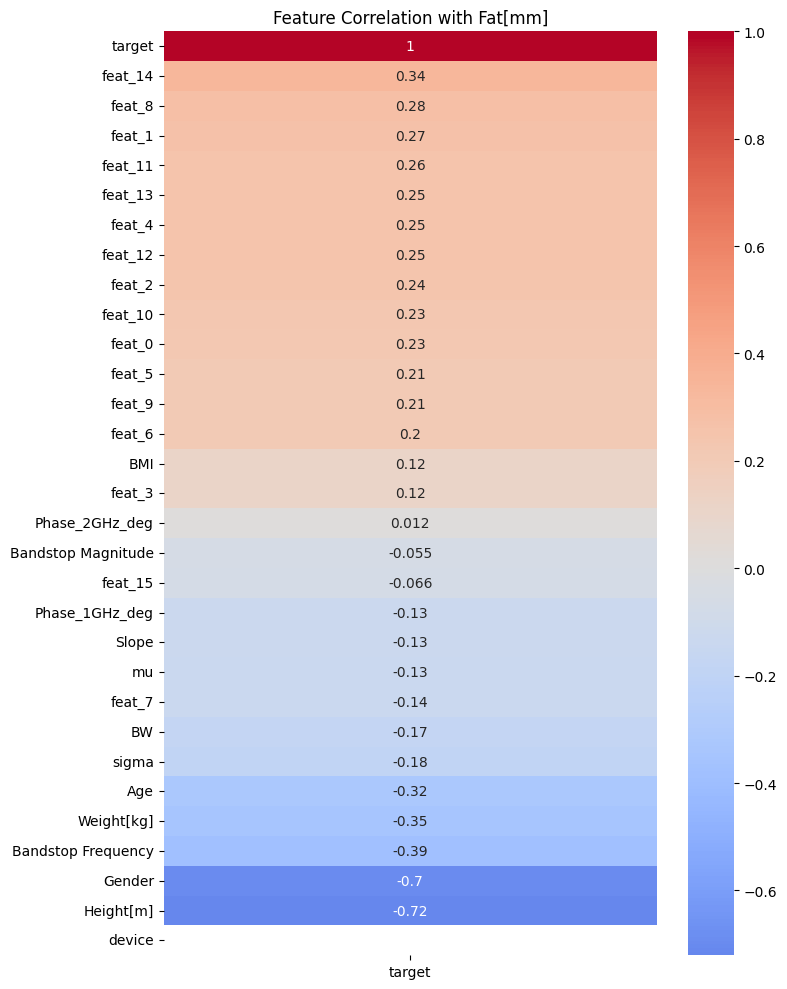

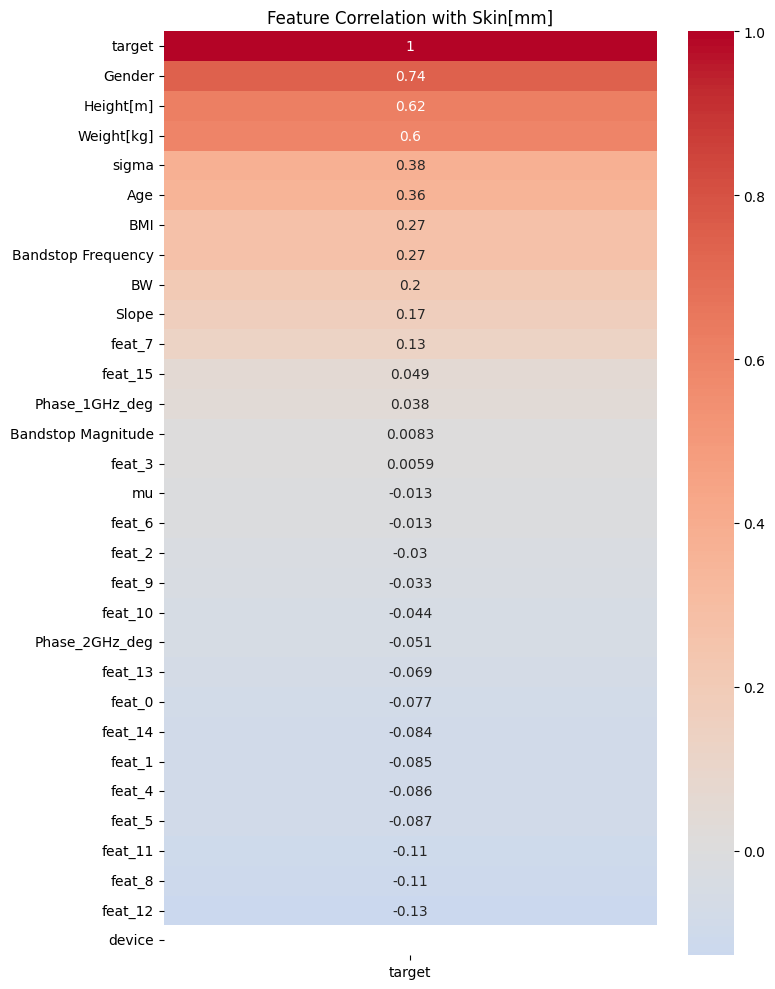

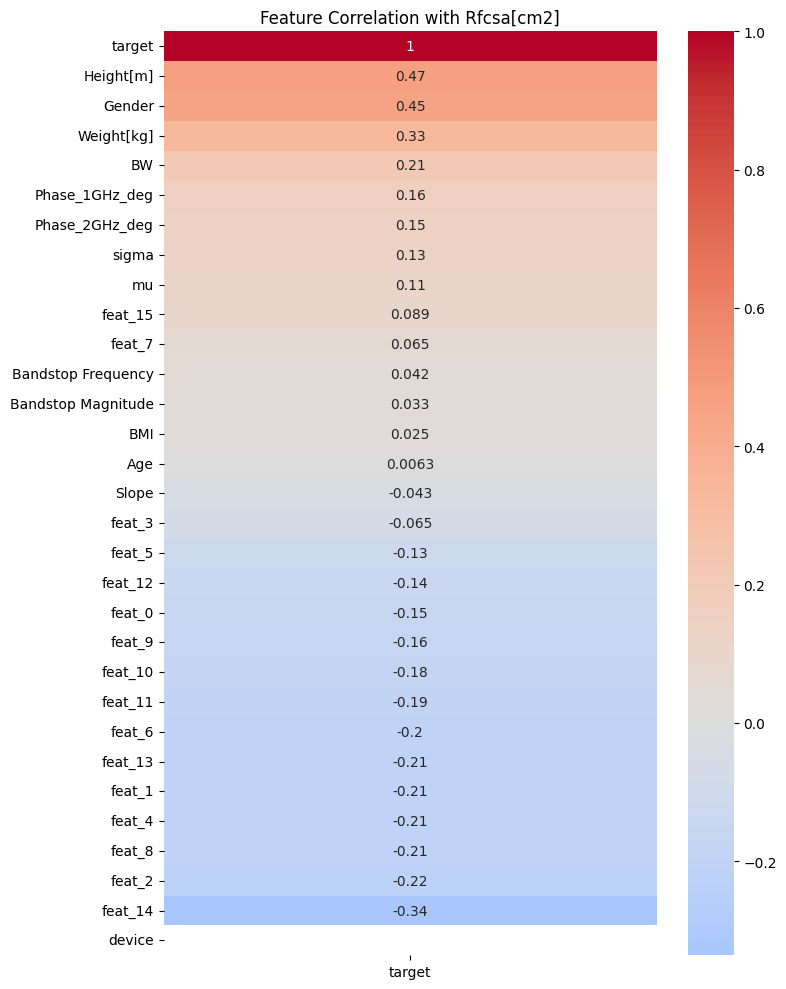

,target
target,1.000000
Height[m],0.465867
Gender,0.451659
Weight[kg],0.333865
BW,0.213368
Phase_1GHz_deg,0.163871
Phase_2GHz_deg,0.148944
sigma,0.130270
mu,0.110618
feat_15,0.089063


In [12]:
path = '/content/drive/MyDrive/Data/prepared data/de_autoencoder_gauss_dataset.csv'
data = pd.read_csv(path)
plot_target_correlation(data, 'Fat[mm]')
plot_target_correlation(data, 'Skin[mm]')
plot_target_correlation(data, 'Rfcsa[cm2]')

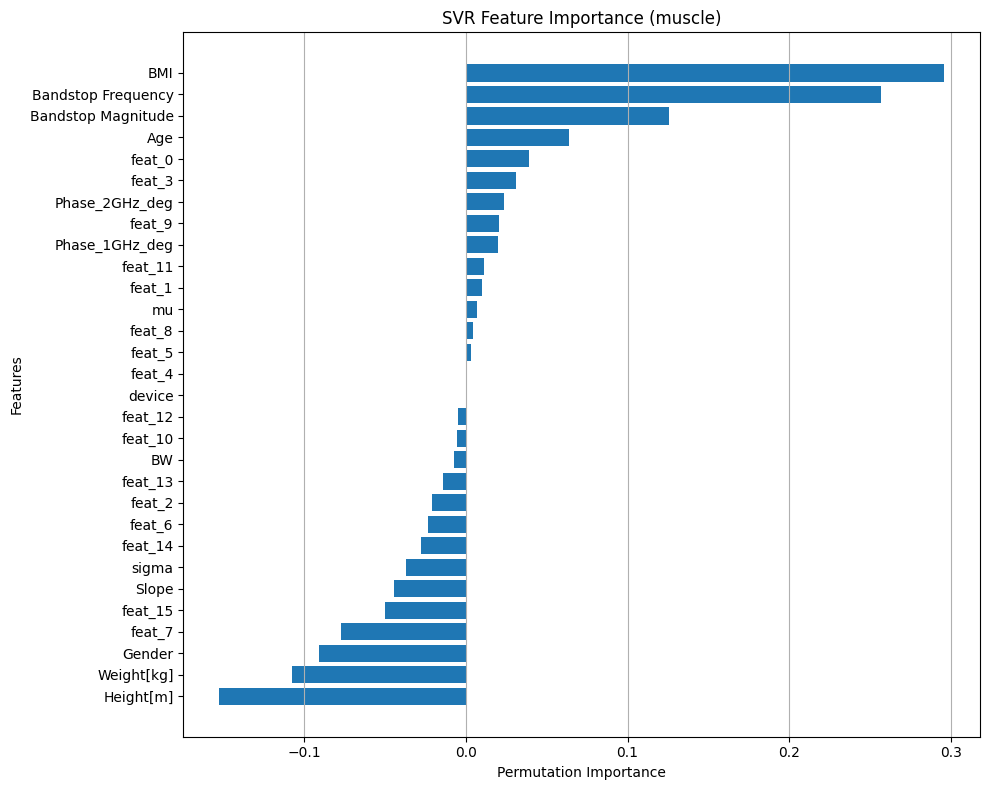

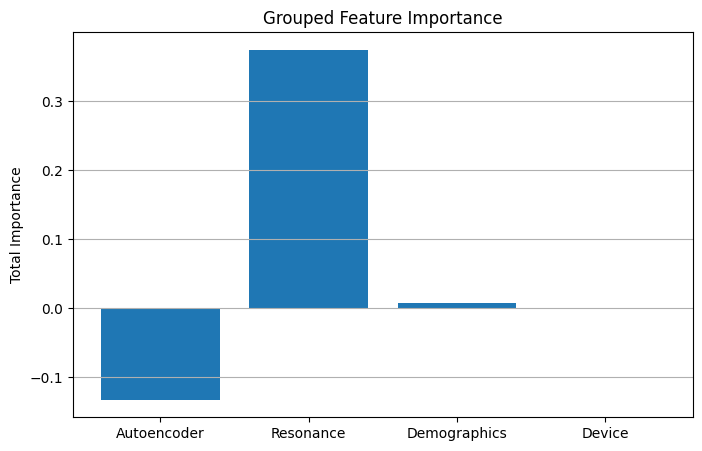

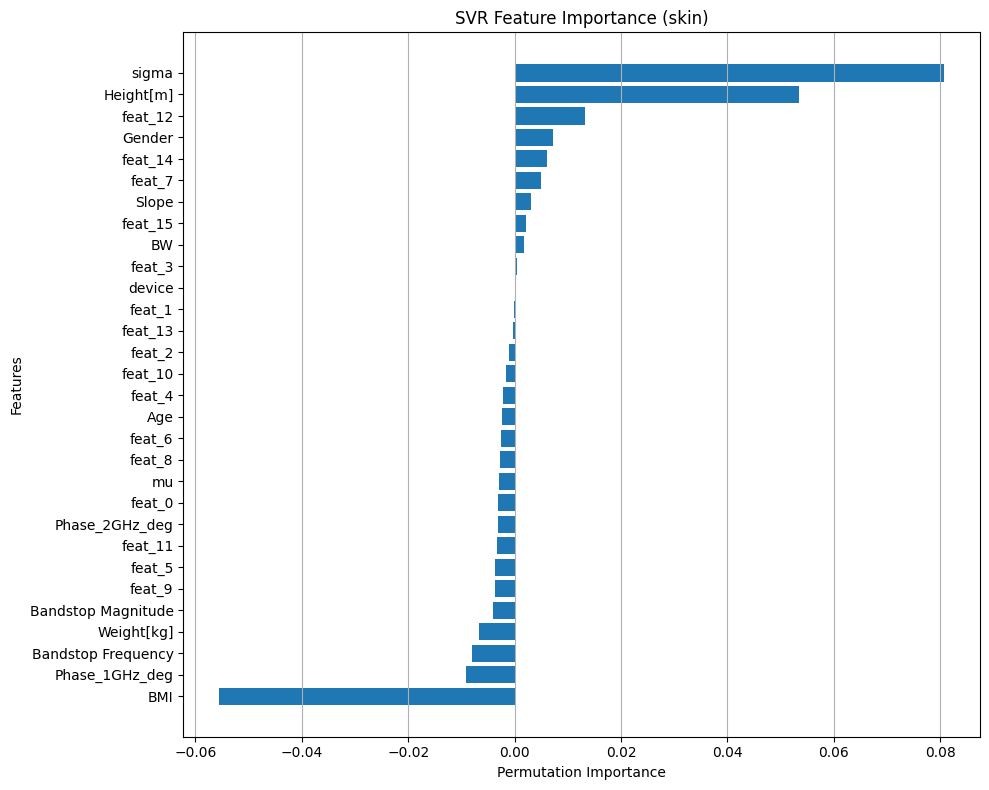

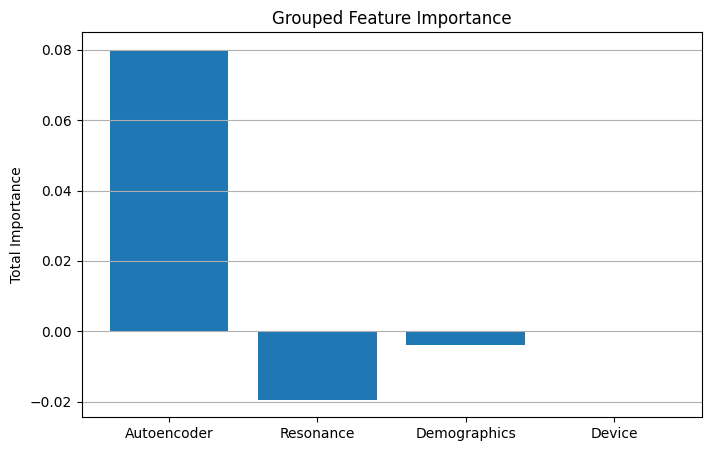

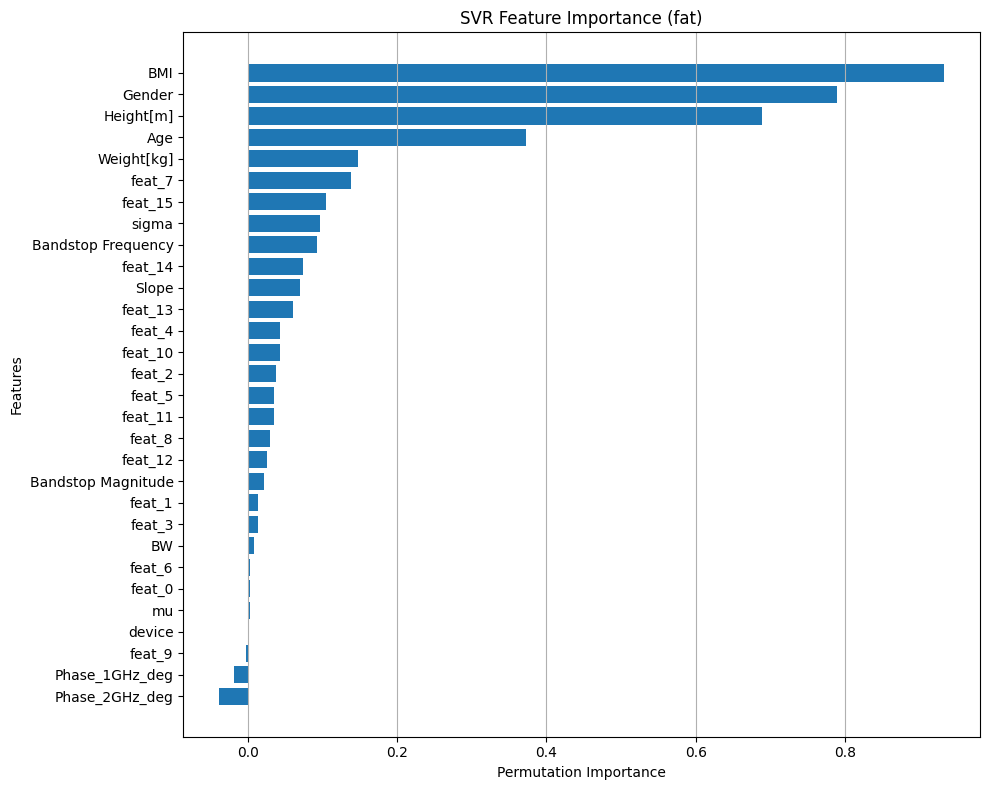

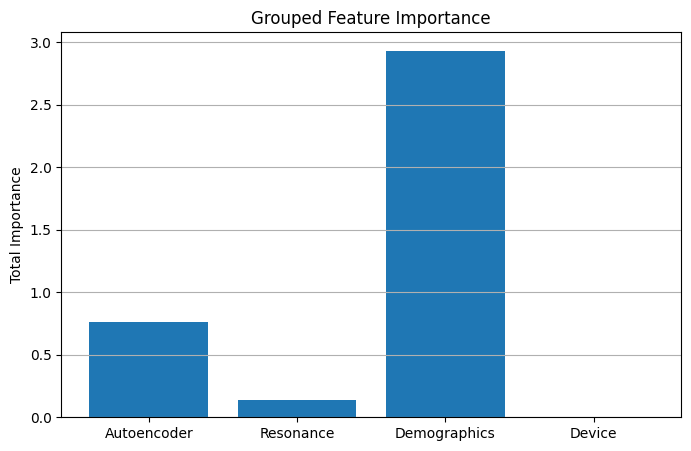

In [18]:
path = '/content/drive/MyDrive/Data/prepared data/de_autoencoder_gauss_dataset.csv'
data = pd.read_csv(path)
for layer in ['muscle','skin','fat']:
  model, X_test, y_test, y_pred, mae, r2 = analyze(data,layer,mode)
  importance_df = plot_feature_importance(
      model,
      X_test,
      y_test,
      title=f"SVR Feature Importance ({layer})")
  group_df = grouped_importance(importance_df)

In [24]:
def analyze(data, layer, params=None):

    muscle = [
        'mu',

        'feat_0','feat_1','feat_3','feat_4','feat_5'
        ,'feat_8','feat_9','feat_11',


        'Bandstop Frequency',
        'Bandstop Magnitude',
        'Phase_1GHz_deg',
        'Phase_2GHz_deg',

        'Age','BMI',
    ]

    fat = [
        'sigma',

        'feat_1','feat_2','feat_3','feat_4','feat_5',
        'feat_7','feat_8','feat_10','feat_11',
        'feat_12','feat_13','feat_14','feat_15',

        'Bandstop Frequency',
        'Bandstop Magnitude',
        'BW',
        'Slope',

        'Age','Gender','Height[m]','Weight[kg]','BMI',

        'device'
    ]

    skin = [
        'sigma',

        'feat_3',
        'feat_7',
        'feat_12','feat_14','feat_15',


        'BW',


        'Gender','Height[m]',

        'device'
    ]

    if layer == 'fat':
        feature_cols = fat
    elif layer == 'muscle':
        feature_cols = muscle
    elif layer == 'skin':
        feature_cols = skin

    X = data[feature_cols].copy()

    if 'Gender' in X.columns:
        X['Gender'] = X['Gender'].map({'M': 1, 'F': 0})
    if 'device' in X.columns:
      X['device'] = X['device'].map({
        'CopperMountain': 0,
        'nanoVNA': 1,
        'NEW protocol': 1})

    if layer == 'muscle':
        y = data['Rfcsa[cm2]']
    elif layer == 'skin':
        y = data['Skin[mm]']
    elif layer == 'fat':
        y = data['Fat[mm]']
    else:
        raise ValueError("layer must be one of: muscle, skin, fat")

    # keep groups aligned before dropping rows
    groups = data['volunteer']

    df = X.copy()
    df['target'] = y
    df['group'] = groups

    df = df.dropna()

    X = df[feature_cols]
    y = df['target']
    groups = df['group']

    splitter = GroupShuffleSplit(
        n_splits=1,
        test_size=0.2,
        random_state=42
    )

    train_idx, test_idx = next(splitter.split(X, y, groups=groups))

    X_train = X.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_train = y.iloc[train_idx]
    y_test = y.iloc[test_idx]

    #Best parameters:
    c, epsilon, gamma, kernel = 10, 0.01, 'scale', 'rbf'

    model = Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR(kernel=kernel, C=c, epsilon=epsilon))
    ])

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return model, X_test, y_test, y_pred, mae, r2

In [26]:
path = '/content/drive/MyDrive/Data/prepared data/de_autoencoder_gauss_dataset.csv'
data = pd.read_csv(path)
result = [['layer','mae','r_square']]
for layer in ['muscle','skin','fat']:
  model, X_test, y_test, y_pred, mae, r2 = analyze(data,layer,mode)
  result.append([layer,mae,r2])

In [27]:
result

[['layer', 'mae', 'r_square'],
 ['muscle', 0.8832976551513902, -2.9917564762583684],
 ['skin', 0.13763407991421386, 0.30028240304888043],
 ['fat', 1.155173520519256, 0.7958519824636114]]